# Derin Öğrenmenin Temellerine Dair Özet

📆 Bu özetin programında neler var?

- ***Giriş***: Dokümantasyonu nasıl okuyalım
- ***1. Bölüm***: Tensorflow ve Keras'ı anlayalım (👨🏻‍🏫 Öğretmen eşliğinde)
- ***2. Bölüm***: Tensorflow vs Numpy? (👨🏻‍🏫 Öğretmen eşliğinde)
- ***3. Bölüm***: Orman Yangınları Zorluğu (👩‍🎓 Öğrenci öncülüğünde)

## Giriş: Dokümantasyonu nasıl okuyalım?

✅ [Keras.io](https://keras.io/getting_started/) yüksek seviye Keras API'sinin dokümantasyonudur:
- Birçok Derin Öğrenme görevi için bol miktarda eğitim içerir
- Daha detaylı geliştirici kılavuzları da dahil
- Aynı zamanda komple Keras API dokümantasyonu
- Her zaman Keras 3 dokümantasyonunu kontrol ettiğinizden emin olun

&nbsp;

✅ [Tensorflow.org](https://www.tensorflow.org/overview) size başvurabileceğiniz iki ana sayfa sağlar:
- [Eğitim](https://www.tensorflow.org/tutorials)
- [Kılavuz](https://www.tensorflow.org/guide)
- Bu eğitimlerin `Colab-Notebook`larını bile çalıştırabilirsiniz

&nbsp;

✅ TensorFlow [API dokümanları](https://www.tensorflow.org/api_docs/python/tf/) Keras için kullandığımız kapsamlı (ve bazen çok düşük seviyeli) TensorFlow arkayüzünün dokümantasyonudur:
- Google Arama'da öncelikle çıkar
- [Bazen](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential), ilgili Eğitimler veya Kılavuzlara referanslar verebilir

# 1️⃣ - Tensorflow ve Keras'ı anlayalım 
_(🧑🏻‍🏫 Öğretmen eşliğinde)_

👉 Hedef: Tensorflow ve Keras kullanarak sahte bir veri seti oluşturmak ve bununla sahte bir modeli eğitmek

### (1) Tensörler?

📚 [Online Kılavuz](https://www.tensorflow.org/guide/tensor)

In [ ]:
# It's OK to import everything for notebook based experimentation!
import tensorflow as tf
import keras
import numpy as np

In [ ]:
# Tensors are wrappers around numpy objects

X = tf.constant([[1., 1., 1.],
                 [1., 1., 1.],
                 [1., 1., 1.]])
X

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [ ]:
tf.ones((3,3))

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [ ]:
x = X.numpy()
x

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)

In [ ]:
# Tensors have a shape
X.shape

TensorShape([3, 3])

In [ ]:
# Tensors can be initialized from Numpy objects
tf.constant(x)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [ ]:
# They can be manipulated with syntax that is similar to Numpy
tf.add(X,X)

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]], dtype=float32)>

In [ ]:
# Conversely, Numpy also accept Tensor elements!
np.add(X,X)

array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]], dtype=float32)

In [ ]:
# Example of a custom MSE loss function using Tensors

def loss(y_true, y_pred):
    err = y_true - y_pred
    return tf.reduce_mean(tf.square(err))

y_true = tf.ones((10,3))
y_pred = tf.ones((10,3)) + 0.1 * tf.random.normal((10,3))

loss(y_true, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=0.01245517>

#### Diğer Tensörler?

**Seyrek Tensörler**
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/sparse_tensors.png">

In [ ]:
sparse_tensor = tf.sparse.SparseTensor(indices=[[0, 0], [1, 2]],
                                       values=[1, 2],
                                       dense_shape=[3, 4])
sparse_tensor.shape

TensorShape([3, 4])

**Düzensiz Tensörler**
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/ragged_tensors.png">

In [ ]:
ragged_list = [
    [0, 1, 2, 3],
    [4, 5],
    [6, 7, 8],
    [9]]

ragged_tensor = tf.ragged.constant(ragged_list)
ragged_tensor.shape

TensorShape([4, None])

### (2) `Sequential API` ile bir sinir ağı oluşturun

👉 Her biri 3 özellik içeren 10 rastgele gözlem `X` ve tek boyutlu bir hedef `y` oluşturalım

In [ ]:
# Let's generate 100 observations of with 10 features for each of them
X = tf.random.uniform((100,10))

In [ ]:
# And create our dummy target as simply the mean of each observation
y = tf.reduce_mean(X, axis=1)
y.shape

TensorShape([100])

👉 "Çalışan" basit bir yoğun model oluşturalım

In [ ]:
from keras import Sequential, Input, layers

In [ ]:
# Usual syntax

model = Sequential()
model.add(Input(shape=(10,)))
model.add(layers.Dense(30, activation='relu'))
model.add(layers.Dense(1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Equivalent
model = Sequential([
    Input(shape=(10,)),
    layers.Dense(30, activation='relu'),
    layers.Dense(1),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# What if we don't specify the Input layer?
model = Sequential()
model.add(layers.Dense(30, activation='relu'))
model.add(layers.Dense(1))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# One can still access all the layers individually
model.layers

[<Dense name=dense_4, built=False>, <Dense name=dense_5, built=False>]

In [ ]:
# And call the layer with a "tensor" as input
x1 = model.layers[0](X)

# x1 is our activation from layer 1, with random (initial) weights
x1.shape

TensorShape([100, 30])

In [ ]:
# x2 is our output
x2 = model.layers[1](x1)
x2.shape

TensorShape([100, 1])

### (3) Keras Input

Neden bunu kullanıyoruz?
```python
keras.Input(shape=(10,))
```
Katmanlarınıza 100 **gerçek** gözlemi geçirmek yerine, benzer şekilde (10,) olan `None` gözleminin bir `keras.Input`'unu geçirin.  

Bu hesaplama optimizasyonu amaçları için kullanılır (bellek ön-tahsisi ve paralelleştirme için ağ grafikleri)

In [ ]:
inputs = keras.Input(shape=(10,))
inputs

<KerasTensor shape=(None, 10), dtype=float32, sparse=False, name=keras_tensor_7>

In [ ]:
model.layers[0](inputs)

<KerasTensor shape=(None, 30), dtype=float32, sparse=False, name=keras_tensor_8>

In [ ]:
x = model.layers[0](inputs) # Input layer
x = layers.Dense(30, activation='relu')(inputs) # First layer output
x = layers.Dense(20, activation='relu')(x) # Second layer output
x = layers.Dense(10, activation='relu')(x) # Third layer output
outputs = layers.Dense(1)(x)               # Final layer output

outputs.shape

(None, 1)

In [ ]:
# Keras allows you to build a model from an input and output layer
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171 (4.57 KB)

 Trainable params: 1,171 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

☝️ Bu model oluşturma yöntemi Keras [Functional API](https://www.tensorflow.org/guide/keras/functional) olarak adlandırılır
- [Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)'nin aksine: `model.add(...)`
- Karmaşık (ardışık olmayan) mimari için zorunludur...
- Dokümanlarda her yerde kullanılır

# 2️⃣ - Tensorflow vs. Numpy?

### Array ve tensör arasındaki fark?

👉 NumPy arrayları ve tf.Tensörleri arasındaki önemli farklar:

1. Tensörler değişmezdir
2. Tensörler hızlandırıcı bellek (GPU, TPU gibi) tarafından desteklenebilir

**Değişmez**

In [ ]:
# an array element can be reassigned

array = np.array([1,1,1])

array[1] = 2

array

array([1, 2, 1])

In [ ]:
# a tensor element can't be reassigned

tensor = tf.constant([1., 1., 1.])

tensor[1] = 2

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

**Hızlandırıcı bellek tarafından desteklenir**

Tensörler hızlandırıcı bellek (GPU, TPU gibi) tarafından desteklenir. Tensör işlemlerinizi gerçekleştireceğiniz işlemciyi manuel olarak seçebilirsiniz.

⏩⏩⏩ [Dokümantasyona](https://www.tensorflow.org/guide/gpu) göz atın.

In [ ]:
# Check CPU's available
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))

Num CPUs Available:  1


In [ ]:
# Check GPU's available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


Bilgisayarınızda GPU olma ihtimali düşük... Kim ücretsiz GPU kullanımı sunuyor? Google! 

👉 **Özete devam etmek ve işleme sürelerini karşılaştırmak için Google Colab'a geçelim.**

In [ ]:
# If you've set up Colab correctly, you should have a GPU avaiable.
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [ ]:
# Matrix multiplication function performing operation and returning us the time.
import time

def time_matmul(types,x):

    start = time.time()

    if types=='numpy':
        np.matmul(x,x)

    else:
        tf.matmul(x,x)

    diff = time.time() - start

    return diff*1000


👇 Bu hücreyi iki kez çalıştırın (ilk çalıştırıldığında, GPU için tensorflow derlemesi biraz zaman alır)

In [ ]:
shape_dim = []
num_time = []
cpu_tf_time = []
gpu_tf_time = []

for shape in range(500,2001,100):

    print(f"Multiplication of shape [{shape},{shape}]")

    # Start with shape 500,500 to 2000,2000 with an increase of 100
    shape_dim.append(shape)

    # Numpy multiplication
    x_np = np.random.uniform(size=[shape,shape])
    num_time.append(time_matmul('numpy',x_np))

    # Tensor in CPU
    with tf.device("CPU:0"):
        x = tf.random.uniform([shape, shape])
        cpu_tf_time.append(time_matmul('cpu',x))

    # Tensor in GPU multiplication
    with tf.device("GPU:0"): #Or GPU:1 for the 2nd GPU, GPU:2 for the 3rd etc.
        x = tf.random.uniform([shape, shape])
        gpu_tf_time.append(time_matmul('gpu',x))

print("Done multiplying!")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(shape_dim, num_time, label="Numpy Array")
plt.plot(shape_dim, cpu_tf_time, label="Tensor in CPU")
plt.plot(shape_dim, gpu_tf_time, label="Tensor in GPU")
plt.grid()
plt.xlabel("Shape of the Matrix")
plt.ylabel("Time in milliseconds")
plt.legend()

👉 **Google Colab'ı nasıl kuracağınıza dair [eğitimimizi](https://kitt.lewagon.com/knowledge/tutorials/data_google_colab) kontrol edin, önümüzdeki günlerde kullanacaksınız**

# 3️⃣ (isteğe bağlı) - Orman Yangınları Zorluğu 
(👩‍🎓Öğrenci öncülüğünde)

### (1) Veri

`tensorflow_dataset` <a href="https://www.tensorflow.org/datasets/catalog/overview">burada</a> bulunabilen birçok `Dataset` sağlar

**`forest_fires`** veri setini yükleyelim. Hedef, yangın tarafından hasara uğrayan alandır (daha fazla detay için https://www.tensorflow.org/datasets/catalog/forest_fires).

In [ ]:
import tensorflow_datasets as tfds
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
area, features = tfds.as_numpy(tfds.load(
    'forest_fires',
    split='train',
    batch_size=-1,
    as_supervised=True,
))

In [ ]:
X = pd.DataFrame(features).values
y = area
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y = area

### (2) Modelinizin genel mimarisini tanımlayın



❓ Keras'ı import edin ve bir Sequential model tanımlayın

In [ ]:
from keras import models

model = models.Sequential()

❓ 50 nöronlu ve `relu` aktivasyon fonksiyonlu bir Dense katman ekleyin. Input şeklini belirtmeyi unutmayın.

In [ ]:
from keras import layers

model.add(Input(shape=(12,)))
model.add(layers.Dense(50, activation="relu"))

❓ 20 nöronlu ve `relu` aktivasyon fonksiyonlu ikinci bir tam bağlantılı katman ekleyin.

In [ ]:
model.add(layers.Dense(20, activation="relu"))

❓ Regresyon görevinize uygun son katmanı ekleyin

In [ ]:
model.add(layers.Dense(1, activation="linear"))

❓ Modelinizin parametre sayısını kontrol edin.

Yoğun Sinir Ağınızın her katmanında yer alan parametre sayılarını anladığınızdan emin olmak için bunları manuel olarak yeniden sayın

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 50)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,691 (6.61 KB)

 Trainable params: 1,691 (6.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
(12*50 + 50) + (50*20 + 20) + (20*1 + 1)

1691

### (3) Modelinizin nasıl eğitildiğini tanımlayın
 

❓ Modeli `adam` `optimizer` ve `mse` `loss` ile derleyin

In [ ]:
model.compile(optimizer='adam',
              loss='mse')

❓ Modeli bu rastgele veri üzerinde çalıştırın; `epochs` ve `batch_size` sayısını seçmeyi unutmayın. Dönen sonucu `history`'de saklayın.

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size=16,
                    epochs=2000,
                    verbose=0)

❓ Model yakınsamasını çizin

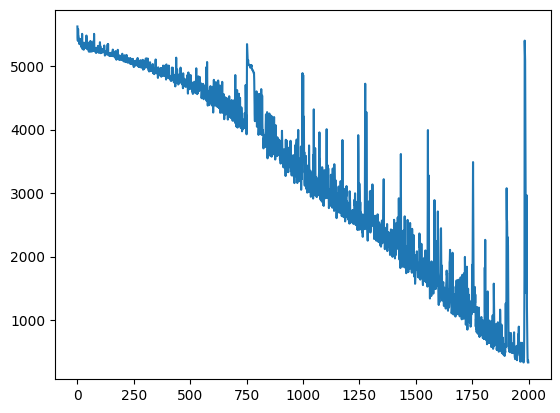

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.show()

❓ Bir `init_model` fonksiyonu içinde derlemesiyle birlikte komple bir model yazın

In [ ]:
def init_model():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(1, activation='linear'))

    model.compile(optimizer='adam',
              loss='mse')

    return model

Modelinizin parametrelerini yeniden başlatmak için bazı verileri eğitmeden önce sistematik olarak bir modeli (init fonksiyonu ile) yeniden oluşturmanız tavsiye edilir.

Az önce yazdığınız model regresyon görevleri için uygundur.

Peki ikili sınıflandırma görevi yapmak istersek?

❓ İkili sınıf sınıflandırma probleminde kullanılan aşağıdakileri değiştireceğiniz başka bir `init_model_2` fonksiyonu yazın:
* mimarinin son katmanı 
* ve derleme yöntemi

In [ ]:
def init_model_2():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
              loss='binary_crossentropy')

    return model

❓ 10 sınıflı bir sınıflandırma problemi için model tanımlayan son fonksiyonu yazın.

In [ ]:
def init_model_3():

    model = models.Sequential()
    model.add(layers.Dense(20, activation='relu'))
    model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy')

    return model